*Dataset From Kaggle:* https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download

Up to now, we've focused on understanding individual variables and relationships between pairs of variables.
Today, we move into multivariate analysis where we deal with many variables at once. When data becomes high-dimentional, patterns are no longer obvious.
In this session, we'll learn:
- Cluster Analysis Using K-Means on Multivariate Data.
- Determination of the optimal number of clusters in K-Means using the Elbow Method and Silhouette Score
- Cluster Profiling and Interpolation in K-Means analysis.

KMeans tries to Minimize distance within clusters, and maximize distance between clusters. Good clustering means items in the same group look alike, and items in the different groups look different. Each data point is assigned to exactly one cluster, and all clusters exist independently.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output during learning

data = pd.read_csv('C:/Users/hasna/Downloads/Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


---

Cluster Analysis Using K-Means
-

K-Means clustering is a fundamental unsupervised learning technique used to identify structure in multivariate data.
When we move into unsupervised learning, we don't have a target variable and instead let the data reveal its own stucture. K-Means is one of the most widely used clustering algorithms for this purpose. Its goal is simple: to group observations that are similar to each other based on multiple variables. What makes K-Means important is not just the algorithm itself, but the way it forces us to think about distance, scale, and interpretation. In practice, clustering is only useful if the results can be explained and acted upon.

In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler

data['mainroad'] = data['mainroad'].replace(['yes', 'no'], [1, 0])
data['guestroom'] = data['guestroom'].replace(['yes', 'no'], [1, 0])
data['basement'] = data['basement'].replace(['yes', 'no'], [1, 0])
data['hotwaterheating'] = data['hotwaterheating'].replace(['yes', 'no'], [1, 0])
data['airconditioning'] = data['airconditioning'].replace(['yes', 'no'], [1, 0])
data['prefarea'] = data['prefarea'].replace(['yes', 'no'], [1, 0])
data = pd.get_dummies(data, columns=['furnishingstatus'], dtype=np.int64)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, init='k-means++', random_state=1)
kmeans.fit(scaled_data)

labels = kmeans.fit_predict(scaled_data)

clustered_data = data.copy()
clustered_data['label'] = labels
clustered_data['label'] = clustered_data['label']

clustered_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,label
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0,0


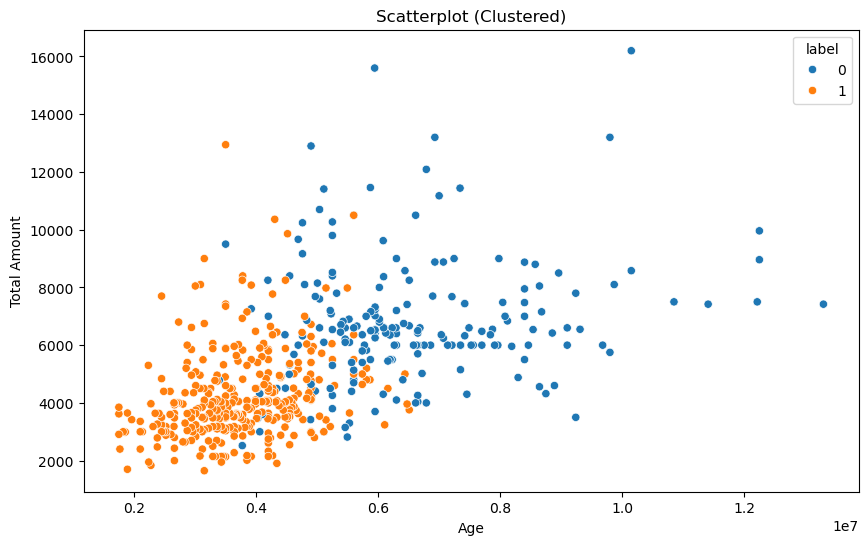

label
1    346
0    199
Name: count, dtype: int64

In [4]:
#Let's visualize the clusters with scatterplot.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=clustered_data, x='price', y='area', hue='label')
ax.set_xlabel('Age')
ax.set_ylabel('Total Amount')
ax.set_title('Scatterplot (Clustered)')
plt.show()

clustered_data['label'].value_counts()

Determination of the Optimal Number of Clusters
-

The elbow method is a visual technique used to decide the optimal number of clusters (K) in K-means clustering. K-means always requires us to choose K in advance, but in real life we usually don’t know how many natural groups exist in the data. The elbow method helps us make an informed, data-driven choice instead of guessing.

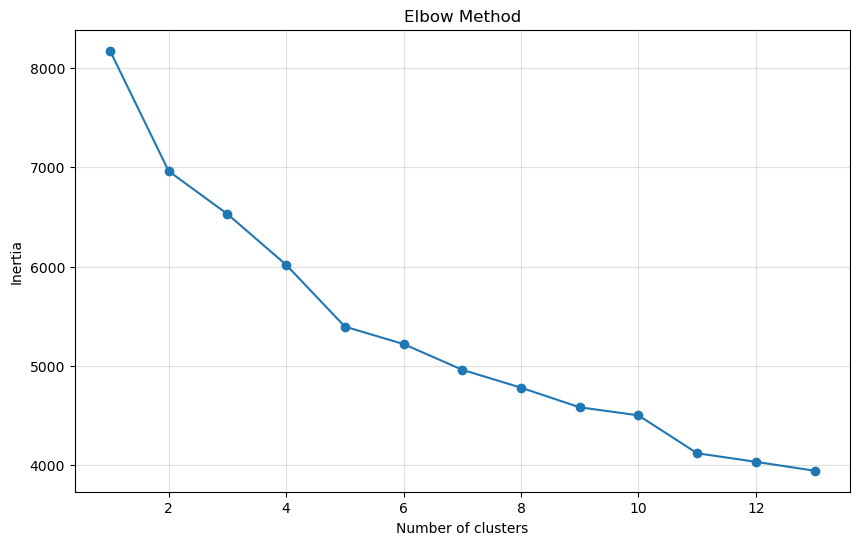

In [5]:
distances = []

#Loop through different numbers of clusters from 1 to 13.
for cluster in range(1, 14):
    #Create a KMeans model with 'cluster' number of clusters.
    kmeans = KMeans(n_clusters=cluster, init='k-means++', random_state=1)
    kmeans.fit(scaled_data)

    #Store the inertia value (WCSS) which measures total within-cluster variance.
    #Lower inertia means tighter, more compact clusters.
    distances.append(kmeans.inertia_)

clusters = pd.DataFrame({'cluster': range(1, 14), 'distances': distances})
clusters

plt.figure(figsize=(10, 6))
plt.plot(clusters['cluster'], clusters['distances'], marker='o')
plt.grid(alpha=0.4)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The optimal number of clusters is where the inertia stops decreasing rapidly. In this plot, that happens around 4 clusters, so K = 4 is a reasonable choice.

---
Silhouette Score
-

The silhouette method is a way to evaluate how well data points are clustered.
For each data point, it compares: how close the point is to its own cluster versus how far it is from the nearest other cluster.
It answers one key question:
Does this point truly belong to its assigned cluster?

+1 → Very well clustered.

0 → Overlapping clusters.

−1 → Likely assigned to the wrong cluster.

The average silhouette score over all points tells us how good the clustering.

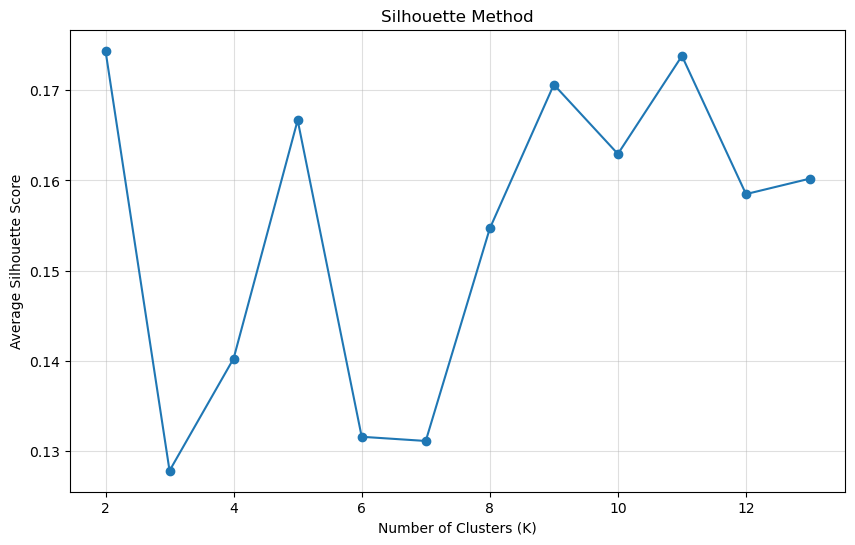

In [6]:
from sklearn.metrics import silhouette_score

K = range(2, 14)
silhouette_avg = []

for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=1)
    kmeans.fit(scaled_data)

    score = silhouette_score(scaled_data, kmeans.fit_predict(scaled_data))
    silhouette_avg.append(score)

plt.figure(figsize=(10, 6))
plt.plot(K, silhouette_avg, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Method")
plt.grid(alpha=0.4)
plt.show()

The silhouette score is highest around K = 2, 5, 9, and 11. Among these, K = 11 has the highest overall score. Lower values (around K = 3, 6, 7) indicate weaker clustering structure.
This means that:The data is best separated when using around 9–11 clusters, with 11 giving the strongest separation. The silhouette method favors cluster separation, not simplicity. So, higher K can sometimes give higher silhouette scores. But more clusters also means more complexity. That’s why we don’t rely on silhouette alone.
However, the silhouette method helps us choose K by maximizing how well clusters are separated, not just how compact they are.

---
Cluster Profiling
-

Cluster profiling is the process of understanding and describing the characteristics of each cluster after clustering has been completed.
K-means tells us which data points belong together, but profiling tells us what makes each group unique. Clustering alone only produces labels.
Profiling turns those labels into meaningful insights.
Without profiling, clusters are just numbers (Cluster 0, Cluster 1, …). But with profiling, clusters become interpretable groups, and decisions can be made based on cluster behavior

In [7]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=1)
labels = kmeans.fit_predict(scaled_data)

clustered_data = data.copy()
clustered_data['label'] = labels

cluster_mean_overall = clustered_data.drop(labels=['label'], axis=1).apply(np.mean).T
cluster_mean_overall = pd.DataFrame(cluster_mean_overall, columns=['mean'])

cluster_mean_overall

,mean
price,4.766729e+06
area,5.150541e+03
bedrooms,2.965138e+00
bathrooms,1.286239e+00
stories,1.805505e+00
mainroad,8.587156e-01
guestroom,1.779817e-01
basement,3.504587e-01
hotwaterheating,4.587156e-02
airconditioning,3.155963e-01


In [8]:
#Grouping clusters and calculate averages.
cluster_mean = clustered_data.groupby('label').mean().T
cluster_mean

label,0,1,2,3,4
price,4.616885e+06,4.717002e+06,7.822152e+06,3.398905e+06,3.742696e+06
area,5.281648e+03,5.274874e+03,6.982122e+03,3.606442e+03,4.609017e+03
bedrooms,2.846154e+00,2.942857e+00,3.475610e+00,2.987013e+00,2.725000e+00
bathrooms,1.153846e+00,1.217143e+00,1.926829e+00,1.233766e+00,1.083333e+00
stories,1.571429e+00,1.651429e+00,3.024390e+00,1.545455e+00,1.541667e+00
mainroad,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
guestroom,2.197802e-01,1.942857e-01,2.926829e-01,9.090909e-02,1.000000e-01
basement,4.945055e-01,3.771429e-01,2.560976e-01,2.987013e-01,3.000000e-01
hotwaterheating,4.395604e-02,6.857143e-02,4.878049e-02,5.194805e-02,8.333333e-03
airconditioning,3.076923e-01,2.342857e-01,7.926829e-01,1.948052e-01,1.916667e-01
